<a href="https://colab.research.google.com/github/nitikasingh12/AI-farmer-Advisor/blob/main/Phishing_Website_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Step 1: Load
df = pd.read_csv("/content/drive/MyDrive/training_data.csv", header=None)

# Step 2: Split tab-separated values
df = df[0].str.split("\t", expand=True)

# Step 3: Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Step 4: Check shape BEFORE naming
print(df.shape)   # MUST be (11055, 31)

# Step 5: Assign feature names
feature_names = [
    'having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Sign',
    'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State',
    'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token',
    'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH',
    'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover',
    'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain',
    'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index',
    'Links_pointing_to_page', 'Statistical_report', 'label'
]

df.columns = feature_names

# Final check
print(df.head())

(11055, 31)
   having_IP_Address  URL_Length  Shortining_Service  having_At_Sign  \
0                 -1           1                   1               1   
1                  1           1                   1               1   
2                  1           0                   1               1   
3                  1           0                   1               1   
4                  1           0                  -1               1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  Favicon  ...  popUpWidnow  Iframe  \

In [ ]:
df.info()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Sign               11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

The dataset consists of multiple features representing characteristics of websites. It contains 30 input features and 1 target variable. All features are numerical and there are no missing values. The dataset is well-structured and suitable for machine learning models.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Sign               11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

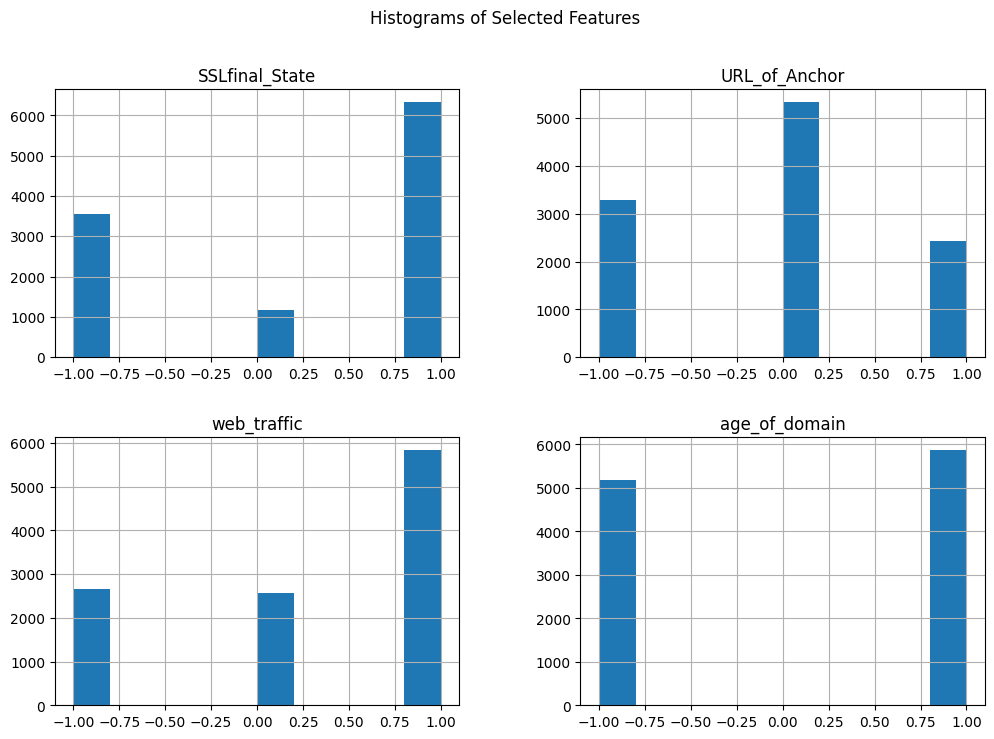

In [ ]:
#📊 Visualization 1: Histogram
import matplotlib.pyplot as plt

df[['SSLfinal_State', 'URL_of_Anchor', 'web_traffic', 'age_of_domain']].hist(figsize=(12,8))

plt.suptitle("Histograms of Selected Features")
plt.show()

The histogram indicates that most features take discrete values such as -1, 0, and 1, confirming that the dataset represents encoded categorical characteristics rather than continuous variables. The dominance of these values suggests that features capture the presence, absence, or suspicious nature of specific website attributes. This kind of distribution is suitable for classification models, as it allows them to clearly distinguish between phishing and legitimate patterns.

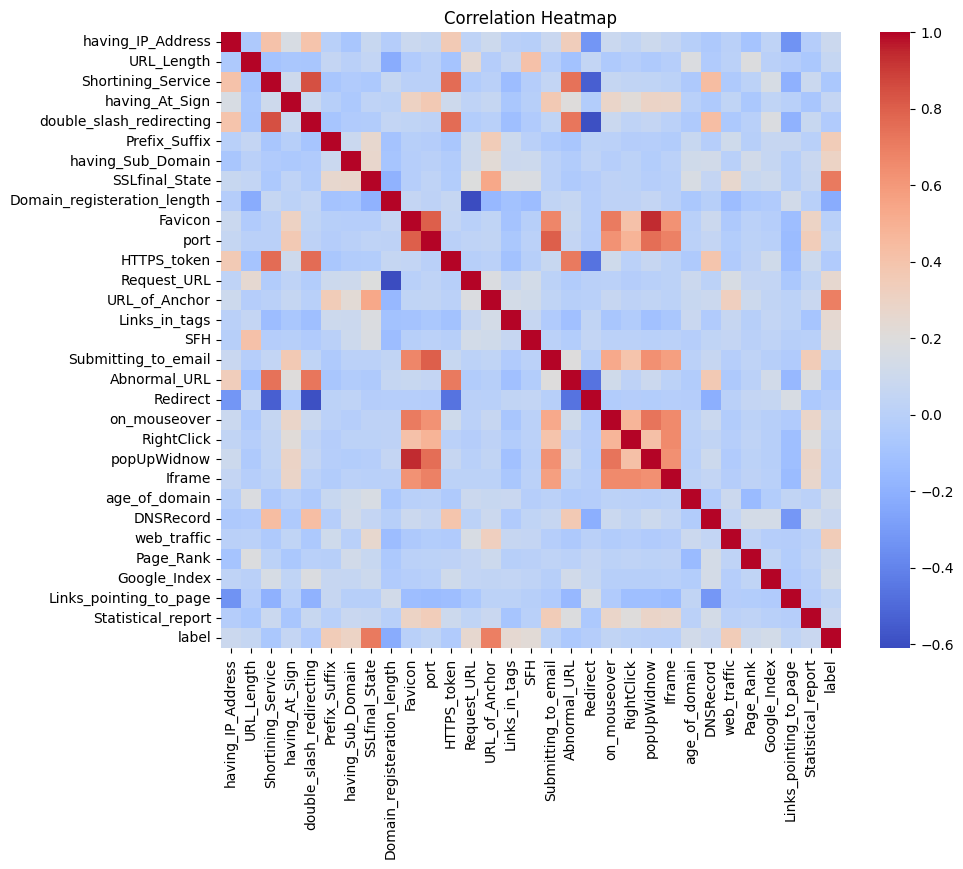

In [ ]:
# 📊 Visualization 2: Correlation Heatmap
# 📊 Visualization 2: Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

The correlation heatmap shows that most features have low to moderate correlation with each other, indicating minimal redundancy in the dataset. A few feature pairs exhibit higher correlation, suggesting some related characteristics, but no strong multicollinearity is observed overall. This is beneficial for machine learning models, as it ensures that each feature contributes unique information toward phishing detection.

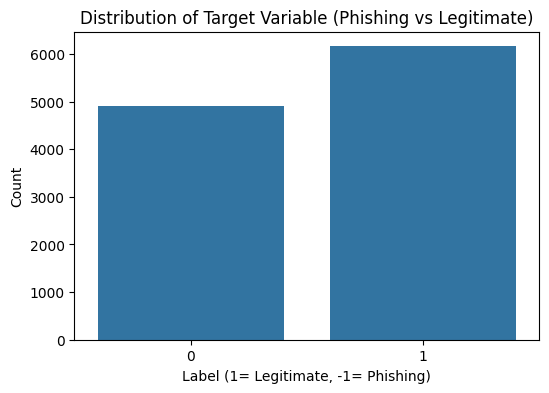

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Distribution of Target Variable (Phishing vs Legitimate)")
plt.xlabel("Label (1= Legitimate, -1= Phishing)")
plt.ylabel("Count")

plt.show()

The count plot shows the distribution of phishing and legitimate websites in the dataset. The classes are relatively balanced, which ensures that the model does not become biased toward one class and improves overall prediction accuracy.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
df["label"] = df["label"].replace(-1, 0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
}

In [ ]:
from sklearn.metrics import *

results = []

for name, model in models.items():
    print(f"\n{name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1, roc])

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)


Logistic Regression
Accuracy: 0.9289914066033469
Precision: 0.9241706161137441
Recall: 0.950446791226645
F1: 0.9371245494593512

Decision Tree
Accuracy: 0.947535052012664
Precision: 0.9565929565929566
Recall: 0.9488220958570268
F1: 0.9526916802610114

Random Forest
Accuracy: 0.9724106739032112
Precision: 0.9672523961661342
Recall: 0.983753046303818
F1: 0.9754329440193314


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"
])

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.972411,0.967252,0.983753,0.975433,0.970958
1,Decision Tree,0.947535,0.956593,0.948822,0.952692,0.947370
0,Logistic Regression,0.928991,0.924171,0.950447,0.937125,0.926244


In [ ]:
sample = X_test.iloc[0].values.reshape(1, -1)
best_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)

best_model.fit(X_train, y_train)

prediction = best_model.predict(sample)

print("Prediction:", prediction)

Prediction: [-1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


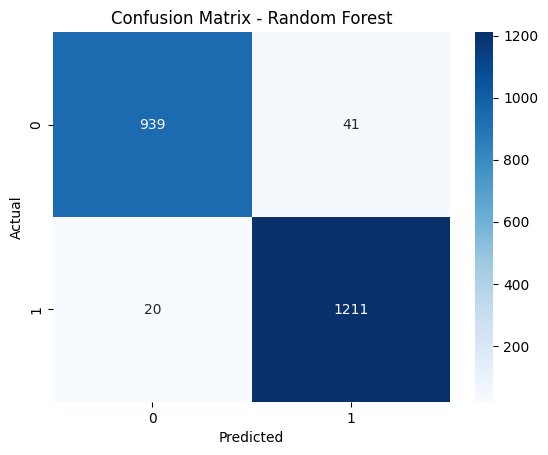

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

best_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

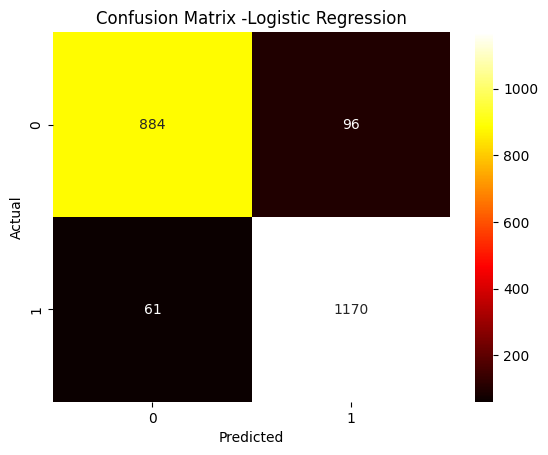

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

LgR_model = LogisticRegression(max_iter=1000)
LgR_model.fit(X_train, y_train)

y_pred = LgR_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='hot')
plt.title("Confusion Matrix -Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

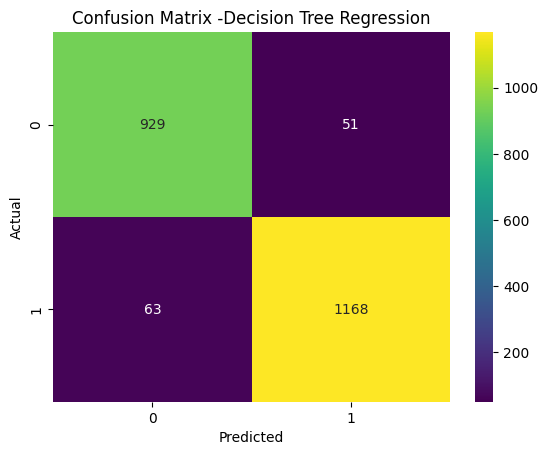

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
Dec_model = DecisionTreeClassifier(max_depth=10)
Dec_model.fit(X_train, y_train)

y_pred = Dec_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title("Confusion Matrix -Decision Tree Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
if prediction[0] == 1:
    print("Legitimate Website")
else:
    print("Phishing Website")

Phishing Website


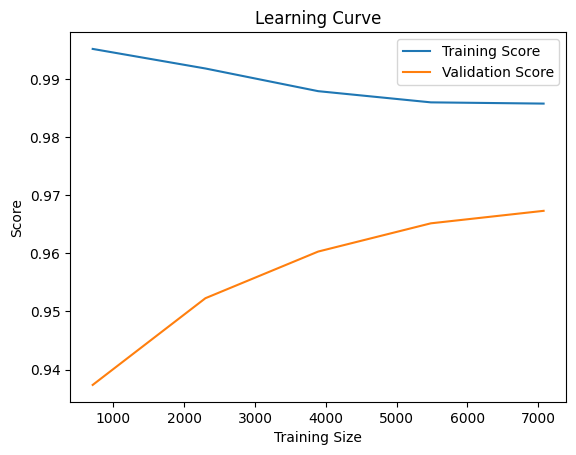

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

The learning curve shows that the training score is consistently high, while the validation score gradually increases as the training size grows. The gap between the training and validation curves reduces over time, indicating that the model is not overfitting. The convergence of both curves suggests that the Random Forest model generalizes well to unseen data and provides stable performance.**bold text**

“Initially, the model slightly overfits, but as more data is used, validation performance improves and stabilizes. This shows good generalization and no major overfitting.”

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)

Specificity: 0.9581632653061225


In [ ]:
import pandas as pd

sample = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

sample

,Actual,Predicted
0,-1,-1
1,-1,-1
2,1,1
3,-1,-1
4,-1,-1
5,1,1
6,1,1
7,1,1
8,1,1
9,-1,-1


In [ ]:
from sklearn.metrics import *

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    results.append([name, acc, prec, rec, spec, f1, roc])

import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall",
    "Specificity", "F1 Score", "ROC-AUC"
])

results_df

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
0,Logistic Regression,0.928991,0.924171,0.950447,0.902041,0.937125,0.926244
1,Decision Tree,0.947083,0.956557,0.948010,0.945918,0.952264,0.946964
2,Random Forest,0.972411,0.967252,0.983753,0.958163,0.975433,0.970958


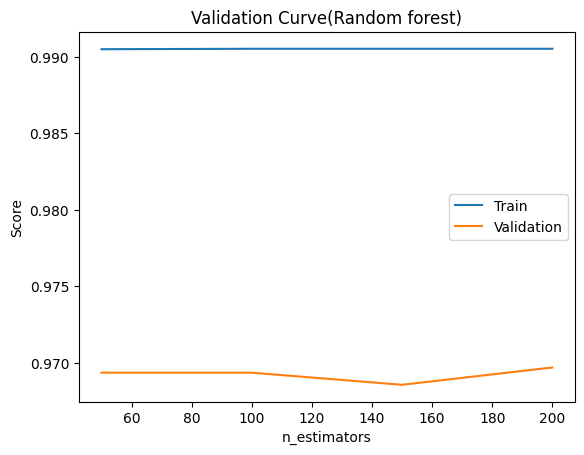

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.model_selection import validation_curve

param_range = [50, 100, 150, 200]

train_scores, test_scores = validation_curve(
    RandomForestClassifier(),
    X_train, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5
)

plt.plot(param_range, train_scores.mean(axis=1), label="Train")
plt.plot(param_range, test_scores.mean(axis=1), label="Validation")

plt.xlabel("n_estimators")
plt.ylabel("Score")
plt.title("Validation Curve(Random forest)")
plt.legend()
plt.show()
plt.savefig("validation_curve.png")

The validation curve shows that the training score remains consistently high across different values of n_estimators, while the validation score remains stable with slight variation. This indicates that increasing the number of trees does not significantly improve performance. The model achieves optimal performance around 100–150 estimators, beyond which there is no noticeable gain. This confirms that the model is well-tuned and not overfitting.

In [ ]:
#Feature importance
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = best_model.feature_importances_

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show top 10
print(feat_df.head(10))

                        Feature  Importance
7                SSLfinal_State    0.342795
13                URL_of_Anchor    0.254104
25                  web_traffic    0.071636
6             having_Sub_Domain    0.060310
5                 Prefix_Suffix    0.042976
14                Links_in_tags    0.040996
15                          SFH    0.019297
12                  Request_URL    0.017196
28       Links_pointing_to_page    0.016138
8   Domain_registeration_length    0.014877


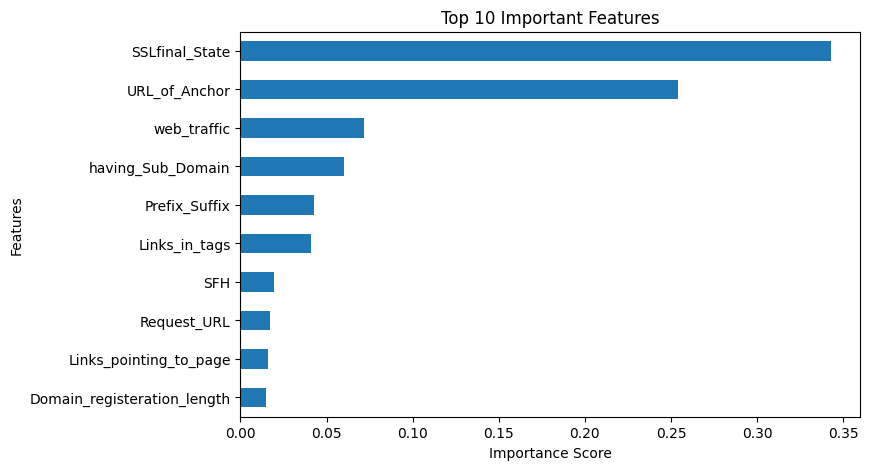

In [ ]:
feat_df.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,5),
    legend=False
)

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig("feature_importance.png")  # SAVE THIS
plt.show()

The feature importance analysis shows that SSL status and URL anchor behavior are the most influential factors in detecting phishing websites. Other features contribute less significantly, indicating that the model relies heavily on a few dominant signals.